In [ ]:
# Minimal single-model workflow: FNO_im2spec -> error estimation -> fused error model

import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt

# Make package importable whether the notebook starts in repo root or notebooks/
repo_root = Path.cwd() if (Path.cwd() / "src" / "nnerror").exists() else Path.cwd().parent
src_root = str((repo_root / "src").resolve())
if src_root not in sys.path:
    sys.path.insert(0, src_root)

from nnerror.networks import FNO_im2spec, CustomDecoder
from nnerror.training_functions import err_estimation, train_model, predict_spectra
from nnerror.plot_functions import plot_only_training_loss, plot_training_loss, \
    plot_error_prediction, plot_spectra, plot_error_prediction_3d
from BEPS_functions import BEPS_image_spectral_pairs, extract_beps_data


In [11]:
def edges_zeroed_image(image: np.ndarray, consider_pixel: int) -> np.ndarray:
    """
    Zero out the edges of a 2D image, keeping only a centered square region.

    Args:
        image: 2D numpy array.
        consider_pixel: Side length of the centered region to keep.
                        Rounded up to the nearest even number so the border
                        is symmetric on both sides.

    Returns:
        A new array, same shape as `image`, with everything outside the
        centered `consider_pixel x consider_pixel` region set to zero.
        If `consider_pixel` is at least as large as the smaller image
        dimension, the image is returned unchanged.

    Raises:
        ValueError: If `consider_pixel` is less than 2, or if `image` is not 2D.
    """
    if image.ndim != 2:
        raise ValueError(f"Expected a 2D image, got shape {image.shape}.")

    if consider_pixel < 2:
        raise ValueError(f"`consider_pixel` must be >= 2, got {consider_pixel}.")

    # Round up to an even number so the border splits evenly on both sides.
    consider_pixel += consider_pixel % 2

    h, w = image.shape
    if consider_pixel >= min(h, w):
        return image.copy()

    # Per-axis offsets so the kept region is centered on both axes.
    diff_h = (h - consider_pixel) // 2
    diff_w = (w - consider_pixel) // 2

    output = np.zeros_like(image)
    output[diff_h:h - diff_h, diff_w:w - diff_w] = \
        image[diff_h:h - diff_h, diff_w:w - diff_w]

    return output


def append_multiscale_data(images: np.ndarray, spectra: np.ndarray, scales: list,
                           coordinates: np.ndarray, include_ori_set: bool = True) -> tuple:
    """
    Append multiscale data to the original dataset by zeroing out edges of the images.
    The scale used for each augmented image is appended to its coordinate vector.

    Args:
        images: Original images, shape (N, H, W).
        spectra: Original spectra, shape (N, S).
        scales: List of integers specifying the side length of the central region to keep.
        coordinates: Original coordinates, shape (N, 2) containing (x, y) per image.
        include_ori_set: If True, the original (un-zeroed) images are also included,
                         with `image_width` appended as their scale.

    Returns:
        A tuple (aug_images, aug_spectra, aug_coordinates) where:
            aug_images: Augmented images, shape (M, H, W).
            aug_spectra: Augmented spectra, shape (M, S).
            aug_coordinates: Augmented coordinates, shape (M, 3) -- (x, y, scale).
            M = N * len(scales), plus N more if include_ori_set is True.
    """
    augmented_images = []
    augmented_spectra = []
    augmented_coordinates = []

    images = images.astype(np.float32)
    coordinates = coordinates.astype(np.float32)
    image_width = images.shape[2]

    assert images.shape[0] == spectra.shape[0], "Number of images and spectra must match."
    assert images.shape[0] == coordinates.shape[0], "Number of images and coordinates must match."

    for scale in scales:

        if scale >= image_width:
            raise ValueError(f"Scale {scale} is too large for image width {image_width}. "
                             f"Must be less than {image_width}.")

        for img, spec, coordinate in zip(images, spectra, coordinates):
            aug_img = edges_zeroed_image(img, consider_pixel=scale)
            augmented_images.append(aug_img)
            augmented_spectra.append(spec)
            augmented_coordinates.append(np.append(coordinate, scale))  # Append scale to coordinates for potential use in model

    if include_ori_set:
        for img, spec, coordinate in zip(images, spectra, coordinates):
            augmented_images.append(img)
            augmented_spectra.append(spec)
            augmented_coordinates.append(np.append(coordinate, image_width))  # Original images use full image_width as scale

    augmented_images = np.array(augmented_images)
    augmented_spectra = np.array(augmented_spectra)
    augmented_coordinates = np.array(augmented_coordinates)

    print(f"Augmented images shape: {augmented_images.shape}, "
          f"Augmented spectra shape: {augmented_spectra.shape}, "
          f"Augmented coordinates shape: {augmented_coordinates.shape}")

    return augmented_images, augmented_spectra, augmented_coordinates


(729, 24, 24) (729, 256) (256,)


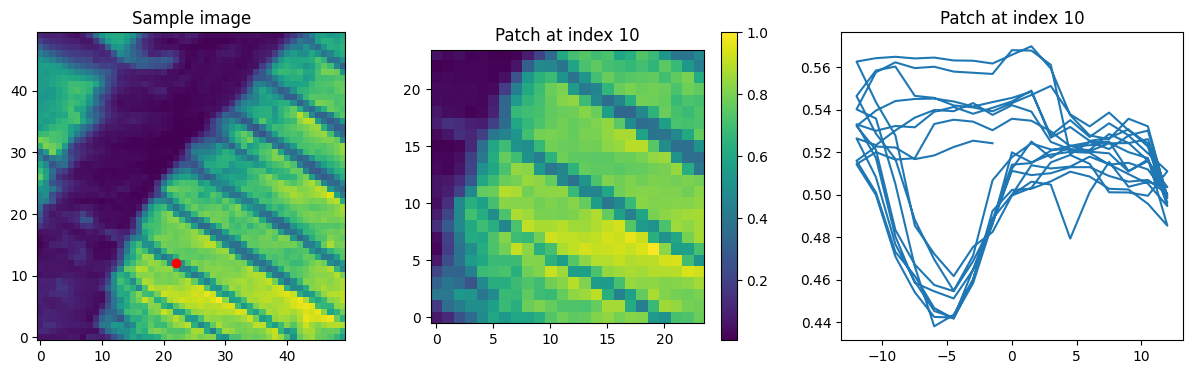

In [12]:
beps_file = "data/BEPS_data/PTO_BEPS_0p85um.npz"
full_image, spectra, v_step = extract_beps_data(beps_file)
images, spectra, coordinates, vstep = BEPS_image_spectral_pairs(beps_file, window_size=24, step=1)

print(images.shape, spectra.shape, vstep.shape)


fig, ax = plt.subplots(1, 3, figsize = (15, 4))


idx = 10

ax[0].imshow(full_image, origin = 'lower')
ax[0].scatter(coordinates[idx, 1], coordinates[idx, 0], c ="r")
ax[0].set_title("Sample image")


im = ax[1].imshow(images[idx], origin = 'lower')
fig.colorbar(im, ax=ax[1])
ax[1].set_title(f"Patch at index {idx}")
ax[2].plot(vstep, spectra[idx])
ax[2].set_title(f"Patch at index {idx}")

plt.show()

In [17]:
images, spectra, scale_coordinates = append_multiscale_data(images, spectra, scales=[8, 12, 16, 20], coordinates = coordinates )

Augmented images shape: (3645, 24, 24), Augmented spectra shape: (3645, 256), Augmented coordinates shape: (3645, 3)


In [18]:
from sklearn.model_selection import train_test_split

images_train, images_test, spectra_train, spectra_test = train_test_split(
    images, spectra, test_size=0.3, random_state=42
)

print("images_train shape:", images_train.shape)
print("images_test shape:", images_test.shape)
print("spectra_train shape:", spectra_train.shape)
print("spectra_test shape:", spectra_test.shape)

images_train shape: (2551, 24, 24)
images_test shape: (1094, 24, 24)
spectra_train shape: (2551, 256)
spectra_test shape: (1094, 256)


In [19]:


print("images shape:", images.shape)
print("spectra shape:", spectra.shape)
in_dim = images[0].shape  # Input dimensions (image height and width)
out_dim = len(spectra[0])  # Output dimensions (spectra length)

images shape: (3645, 24, 24)
spectra shape: (3645, 256)


100%|██████████| 10/10 [01:02<00:00,  6.22s/it]


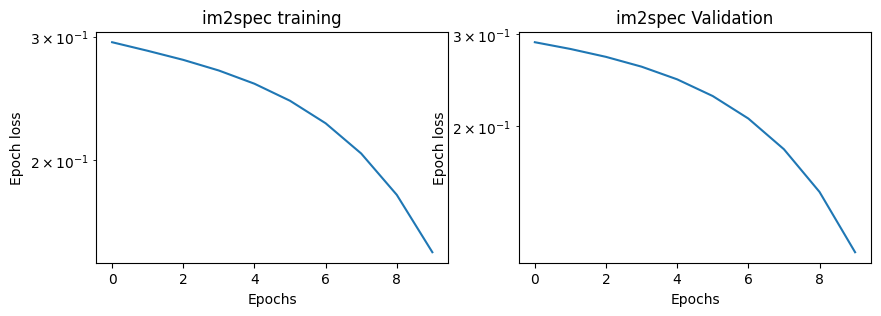

im2spec final train loss: 0.14791689813137054
im2spec final internal val loss: 0.11499641835689545
im2spec held-out test loss: 0.11539353430271149


In [20]:

# ----------------------------
# 2) Fit FNO_im2spec model
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
imspec_model = FNO_im2spec(
    target_size=out_dim,
    latent_dim=8,
    hidden_channels=32,
    n_modes=(8, 8),
    n_layers=4,
).to(device)

im2spec_training_dataset = TensorDataset(
    torch.tensor(images_train, dtype=torch.float32),
    torch.tensor(spectra_train, dtype=torch.float32),
)

# train_model creates its own validation split from the dataset above.
# Keep images_test/spectra_test as an external held-out test set.
n_epochs_im2spec = 10
plot_im2spec_training = True

imspec_model, im2spec_train_loss, im2spec_val_loss = train_model(
    imspec_model,
    im2spec_training_dataset,
    n_batches=1,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_im2spec,
    partial_train=False,
)

if plot_im2spec_training:
    plot_only_training_loss([im2spec_train_loss], [im2spec_val_loss])

imspec_model.eval()
with torch.no_grad():
    x_test = torch.tensor(images_test, dtype=torch.float32, device=device)
    y_test = torch.tensor(spectra_test, dtype=torch.float32, device=device)
    test_pred = imspec_model.predict(x_test)
    im2spec_test_loss = torch.nn.functional.mse_loss(test_pred, y_test).item()

print("im2spec final train loss:", im2spec_train_loss[-1])
print("im2spec final internal val loss:", im2spec_val_loss[-1])
print("im2spec held-out test loss:", im2spec_test_loss)


In [22]:

# ----------------------------
# 3) Build error targets using err_estimation
# ----------------------------
error_mean, error_std, error_vector = err_estimation(imspec_model, images_train, spectra_train)
error_targets = error_mean.astype(np.float32).reshape(-1, 1)

print("error_mean shape:", error_mean.shape)
print("error_vector shape:", error_vector.shape)
print("error_targets shape:", error_targets.shape)

# ----------------------------
# 4) Fuse im2spec encoder with CustomDecoder
# ----------------------------
with torch.no_grad():
    latent_dim = imspec_model.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]

error_model = CustomDecoder(encoder=imspec_model.encoder, embed_dim=latent_dim, target_size=1).to(device)


error_mean shape: (2551,)
error_vector shape: (2551, 256)
error_targets shape: (2551, 1)


100%|██████████| 10/10 [00:55<00:00,  5.59s/it]


error model final train loss: 0.013319272547960281
error model final val loss: 0.013316405937075615


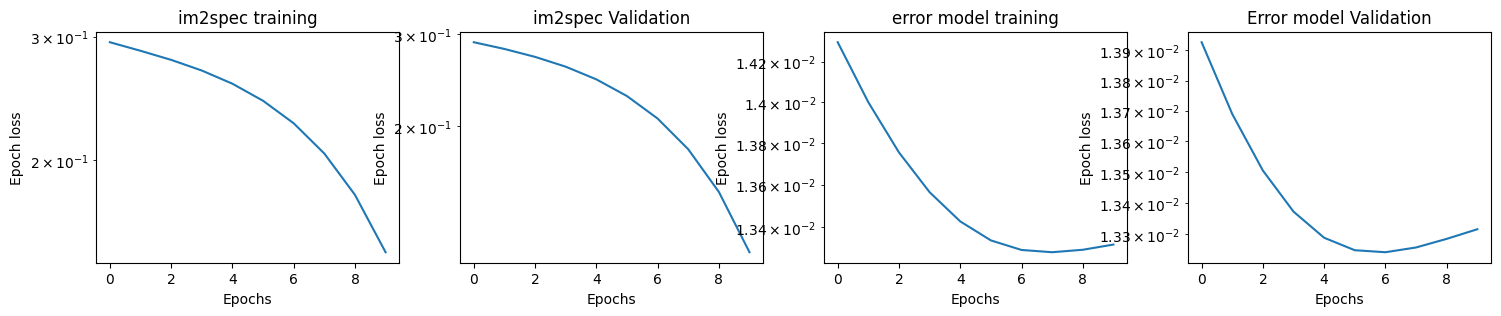

In [24]:

# ----------------------------
# 5) Train error model on images and estimated errors
# ----------------------------



error_training_dataset = TensorDataset(
    torch.tensor(images_train, dtype=torch.float32),
    torch.tensor(error_targets, dtype=torch.float32),
)

n_epochs_error = 10
error_model, error_train_loss, error_val_loss = train_model(
    error_model,
    error_training_dataset,
    n_batches=1,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_error,
    partial_train=True,
)

print("error model final train loss:", error_train_loss[-1])
print("error model final val loss:", error_val_loss[-1])

plot_training_loss([im2spec_train_loss], [im2spec_val_loss], error_train_loss, error_val_loss)

In [25]:
#Predict errors on the entire dataset using the trained error model
predicted_errors = predict_spectra(error_model, images, ensemble=False)
print("predicted_errors shape:", np.asarray(predicted_errors).shape)
print("predicted_errors range:", float(np.min(predicted_errors)), float(np.max(predicted_errors)))

predicted_errors shape: (3645,)
predicted_errors range: 0.30542346835136414 0.3054471015930176


In [35]:
from nnerror.training_functions import distance_acq_fn
from nnerror.plot_functions import plot_error_prediction, plot_spectra

aq_ind, aq_fn = distance_acq_fn(predicted_errors, beta = 0, lambda_ = 1, sample_next_points = 1, exclude_indices = [])
print(aq_fn.shape)


(3645,)


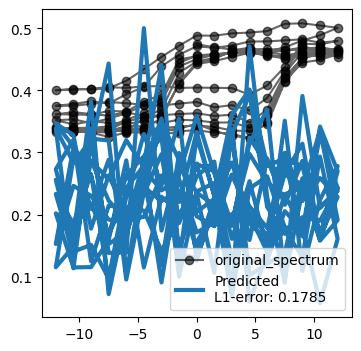

In [28]:
for ind in aq_ind:

    # Acquisition point
    next_coordinate = scale_coordinates[ind]
    predicted_spectra = predict_spectra(imspec_model, images[ind:ind+1], ensemble = False)

    spectral_error, _, _ = err_estimation(imspec_model, images[ind:ind+1], spectra[ind:ind+1])
    # error_log.append(spectral_error.mean())
    plot_spectra([predicted_spectra], spectra[ind], spectral_error.mean(), xdata = vstep)

C:\Users\ggn\AppData\Local\Temp\ipykernel_26456\3098274078.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgba = cm.get_cmap(cmap_name)(norm)


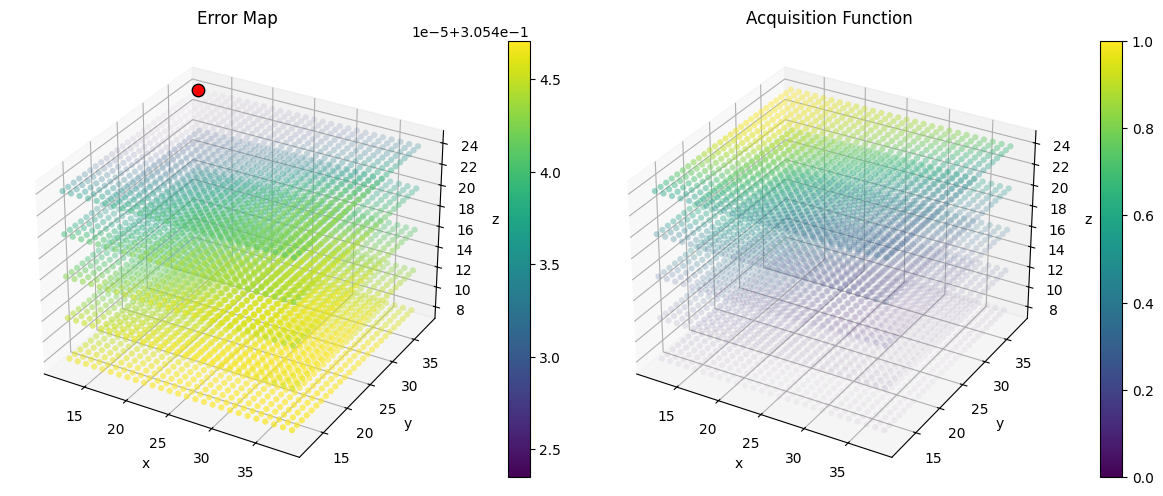

In [40]:
plot_error_prediction_3d(predicted_errors, aq_fn, scale_coordinates, aq_ind, alpha_scale=True)